In [1]:
# regressao linear - dataset diabetes
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
# dataset progressao de diabetes 1 ano após avaliacao (valor continuo)
dataset = load_diabetes()

x = dataset.data # 10 atributos
y = dataset.target # valor continuo

# nesse caso o não é 0 e 1 o valor é continuo
print("Features:", dataset.feature_names)
print("Shape X:", x.shape)
print("Exemplo de y (primeiros 5):", y[:5])

Features: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']
Shape X: (442, 10)
Exemplo de y (primeiros 5): [151.  75. 141. 206. 135.]


In [4]:
# split treino
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

print("Treino:", x_train.shape)
print("Test:", x_test.shape)

Treino: (353, 10)
Test: (89, 10)


In [7]:
# treinar o modelo
modelo = LinearRegression()
modelo.fit(x_train, y_train)

# Ver os coeficientes aprendidos (um por feature)
for nome, coef in zip(dataset.feature_names, modelo.coef_):
    print(f"{nome:>6}: {coef:.2f}")

   age: 37.90
   sex: -241.96
   bmi: 542.43
    bp: 347.70
    s1: -931.49
    s2: 518.06
    s3: 163.42
    s4: 275.32
    s5: 736.20
    s6: 48.67


In [8]:
# avaliacao com MSE e R²
y_pred = modelo.predict(x_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2  = r2_score(y_test, y_pred)

print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}") # mesmo unidade que y erro médio em pontos
print(f"R²: {r2:.4f}") # 0 = péssimo, 1 = perfeito
# MSE Erro quadrático médio penaliza erros grandes
# RMSE Raiz do MSE interpretável na mesma escala de y
# R²% da variância explicada pelo modelo o mais importante

MSE: 2900.19
RMSE: 53.85
R²: 0.4526


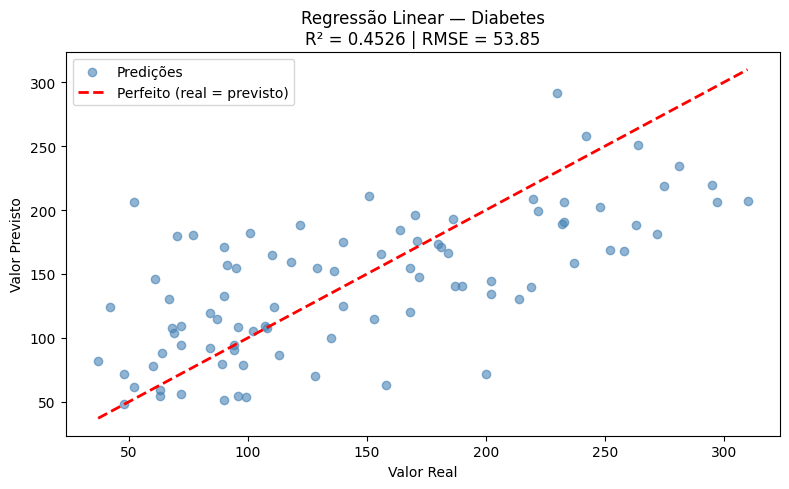

In [9]:
# grafico real x previsto

plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.6, color='steelblue', label='Predições')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', linewidth=2, label='Perfeito (real = previsto)')

plt.xlabel("Valor Real")
plt.ylabel("Valor Previsto")
plt.title(f"Regressão Linear - Diabetes\nR² = {r2:.4f} | RMSE = {rmse:.2f}")
plt.legend()
plt.tight_layout()
plt.show()

# Quanto mais próximo os pontos estiverem da linha vermelha, melhor o modelo

In [10]:
# compracao rapida linear vs logisitca
# Resumo conceitual no próprio notebook como referência futura
resumo = {
    "Regressão Linear": {
        "Prevê": "Valor contínuo (ex: 150.3)",
        "Problema": "Regressão",
        "Métrica": "R², RMSE, MSE",
        "Exemplo": "Progressão do diabetes"
    },
    "Regressão Logística": {
        "Prevê": "Probabilidade → classe (ex: 0 ou 1)",
        "Problema": "Classificação",
        "Métrica": "Accuracy, AUC-ROC, F1",
        "Exemplo": "Tumor maligno ou benigno"
    }
}

for nome, info in resumo.items():
    print(f"\n{'='*40}")
    print(f"  {nome}")
    print(f"{'='*40}")
    for k, v in info.items():
        print(f"  {k}: {v}")


  Regressão Linear
  Prevê: Valor contínuo (ex: 150.3)
  Problema: Regressão
  Métrica: R², RMSE, MSE
  Exemplo: Progressão do diabetes

  Regressão Logística
  Prevê: Probabilidade → classe (ex: 0 ou 1)
  Problema: Classificação
  Métrica: Accuracy, AUC-ROC, F1
  Exemplo: Tumor maligno ou benigno
